# Feature scaling: Standardization

# STANDARDIZATION (StandardScaler)

- Standardization
    - It is a feature scaling technique
    - It transforms data so that:
    - Mean becomes 0
    - Standard deviation becomes 1
    - Formula:
        - (Value − Mean) / Standard Deviation
    - Values can be negative, zero, or positive
    - Minimum does NOT become 0

- Why we need Standardization
    - Different features can have different scales
    - Example:
        - Alcohol → 10–15
        - Malic acid → 0–5
    - Large scale features can dominate smaller ones
    - Important for:
        - KNN
        - SVM
        - Logistic Regression
        - Neural Networks
        - Gradient Descent based models
    - It gives each feature a fair chance

- Important Rule
    - Always split data first
    - Then apply scaling
    - Test data must remain unseen

- Workflow
    - Step 1: Separate Features and Target
        - X → input features
        - y → output (class label)
    - Step 2: Train-Test Split
        - Training data → model learns
        - Test data → model evaluation
        - Test data should never be used during learning

- StandardScaler
    - Import:
        - from sklearn.preprocessing import StandardScaler
    - Create object:
        - scaler = StandardScaler()
    - fit()
        - Learns mean of each feature
        - Learns standard deviation of each feature
        - Only used on training data
    - transform()
        - Applies (value − mean) / std
        - Used on both training and test data

- Code Flow
    - scaler.fit(X_train)
    - X_train_scaled = scaler.transform(X_train)
    - X_test_scaled = scaler.transform(X_test)

- Does Standardization change shape?
    - No
    - Shape remains same
    - Only axis scale changes
    - Relative pattern remains same

- Data Leakage Warning
    - Never use test data in fit()
    - fit → only training data
    - transform → training and test data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 



In [11]:
df = pd.read_csv('wine_data.csv', header=None)
df = df.iloc[:, :3]
df.columns = ['Class label','Alcohol','Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape #asking for info no (), if asking to do something () yes

((124, 2), (54, 2))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler ()
scaler.fit(X_train) #fit the scaler to the training data
X_train_scaled = scaler.transform(X_train) #transform the training data
X_test_scaled = scaler.transform(X_test) #transform the test data

In [16]:
X_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [17]:
X_train_scaled

array([[ 0.91083058, -0.46259897],
       [-0.95609928, -0.96608672],
       [ 0.35952243,  1.67501572],
       [ 0.22169539,  1.0478643 ],
       [ 1.09877654, -0.77175811],
       [-0.16672625,  0.78287075],
       [ 1.07371707,  1.53368582],
       [ 0.39711162, -0.58626262],
       [ 0.08386836,  1.30402474],
       [-0.59273709, -1.01025231],
       [-0.86839117, -0.8600893 ],
       [-0.2669641 ,  0.92420064],
       [-0.02889922,  0.94186688],
       [ 0.86071165, -1.0014192 ],
       [ 0.22169539, -0.02094304],
       [-0.76815332, -1.27524587],
       [-0.64285602, -0.762925  ],
       [-1.46981823, -0.23293788],
       [ 0.32193324,  1.41002216],
       [ 1.39949007, -0.19760541],
       [-1.72041285, -0.91308801],
       [ 0.00868997, -0.63042822],
       [-0.2669641 ,  0.00555632],
       [ 0.62264677, -0.63042822],
       [-1.90835881,  1.19802732],
       [-1.14404524, -0.19760541],
       [-1.4572885 , -0.80709059],
       [ 0.58505758,  1.16269484],
       [-0.98115874,

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled

,Alcohol,Malic acid
0,0.910831,-0.462599
1,-0.956099,-0.966087
2,0.359522,1.675016
3,0.221695,1.047864
4,1.098777,-0.771758
...,...,...
119,-1.457289,-0.586263
120,-0.768153,-1.072084
121,-0.705505,-0.683427
122,1.148895,-0.621595


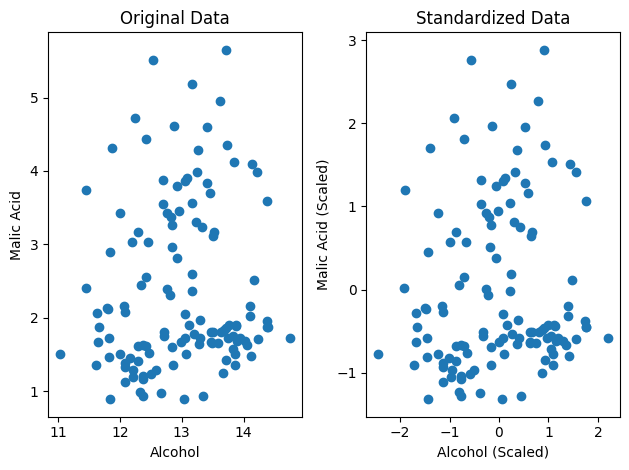

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2)   # 1 row, 2 columns

# First plot
ax[0].scatter(X_train.iloc[:, 0], X_train.iloc[:, 1])
ax[0].set_title("Original Data")
ax[0].set_xlabel("Alcohol")
ax[0].set_ylabel("Malic Acid")

# Second plot
ax[1].scatter(X_train_scaled.iloc[:, 0], X_train_scaled.iloc[:, 1])
ax[1].set_title("Standardized Data")
ax[1].set_xlabel("Alcohol (Scaled)")
ax[1].set_ylabel("Malic Acid (Scaled)")

plt.tight_layout()
plt.show()

In [21]:
X_train_scaled.describe()

,Alcohol,Malic acid
count,1.240000e+02,1.240000e+02
mean,-3.771177e-15,-4.571836e-16
std,1.004057e+00,1.004057e+00
min,-2.447137e+00,-1.319411e+00
25%,-7.775506e-01,-6.856352e-01
50%,7.133863e-02,-4.405162e-01
75%,8.231225e-01,7.629962e-01
max,2.213923e+00,2.885153e+00


In [22]:
X_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


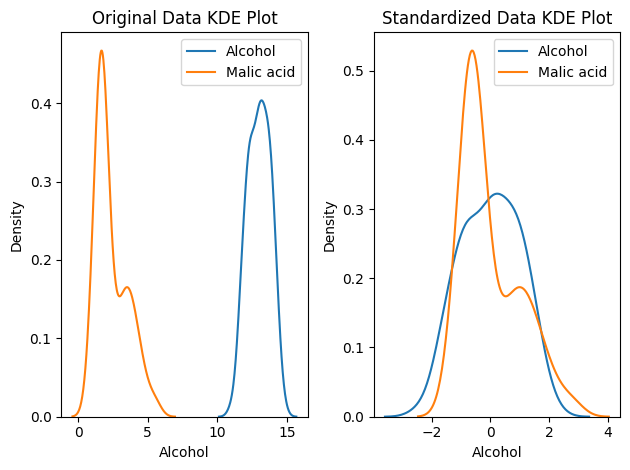

In [27]:
fig, (ax1,ax2) = plt.subplots(1,2)
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.set_title("Original Data KDE Plot")
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.set_title("Standardized Data KDE Plot")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()